In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# KcELECTRA는 AutoTokenizer를 사용하여 간편하게 로드합니다.
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    AdamW 
)

# 평가 및 데이터 분할
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# 실험 기록 (W&B)
import wandb 

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. 재현성을 위한 시드 고정

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # CuDNN 결정론적 설정 (재현성 강화)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
# 2. GPU 확인
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    # VRAM 성능을 활용하기 위해 정보 출력
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

True
사용 디바이스: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


In [4]:
# 3. KcELECTRA 설정
# 구어체 및 대화 데이터셋(DKTC)에 가장 최적화된 v2022 모델을 사용합니다.
model_name = 'beomi/KcELECTRA-base-v2022'

# AutoTokenizer를 사용하면 모델 이름에 맞는 토크나이저를 자동으로 로드합니다.
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# ============================
# 실험 설정값 (KcELECTRA 최적화)
# ============================
CONFIG = {
    # 1. 모델 설정
    'model_name': 'beomi/KcELECTRA-base-v2022', # KcELECTRA 공식 모델명
    'num_labels': 5,                   # 분류할 클래스 개수 (협박, 갈취 등 5종)

    # 2. 데이터 경로 (본인의 환경에 맞게 수정 필요)
    'data_path': '../data/processed/train_processed.csv', 
    'test_path': '../data/raw/test.csv',
    'save_dir': '../models/kcelectra_v2022_experiment',

    # 3. 토크나이저 및 문장 길이
    'max_length': 512, 

    # 4. 학습 하이퍼파라미터
    'epochs': 3,
    'batch_size': 16,         # 50,000개의 단어 사전을 가지므로 32->16 으로 조정
    'learning_rate': 2e-5,    # KcELECTRA 전이학습 권장 학습률
    'warmup_ratio': 0.1,      # 초기 학습 안정화를 위한 웜업 비율
    'val_ratio': 0.1,         # 검증 데이터셋 비율 (10%)

    # 5. 실험 기록 및 관리
    'use_wandb': True,        # W&B 사용 여부
    'project_name': 'DKTC-DLthon',
    'run_name': 'KcELECTRA-v2022-F1-v1'
}

# 저장 디렉토리 생성
os.makedirs(CONFIG['save_dir'], exist_ok=True)

# 6. 레이블 매핑 
LABEL_MAP = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일상 대화': 4
}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}

print('✅ 실험 설정값 확인:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

✅ 실험 설정값 확인:
  model_name: beomi/KcELECTRA-base-v2022
  num_labels: 5
  data_path: ../data/processed/train_processed.csv
  test_path: ../data/raw/test.csv
  save_dir: ../models/kcelectra_v2022_experiment
  max_length: 512
  epochs: 3
  batch_size: 16
  learning_rate: 2e-05
  warmup_ratio: 0.1
  val_ratio: 0.1
  use_wandb: True
  project_name: DKTC-DLthon
  run_name: KcELECTRA-v2022-F1-v1


In [11]:
# 데이터 로드
df = pd.read_csv(CONFIG['data_path'])
test_df = pd.read_csv(CONFIG['test_path'])

print('전체 학습 데이터:', df.shape)
print('테스트 데이터:', test_df.shape)
print()
print('클래스 분포:')
print(df['class'].value_counts())

전체 학습 데이터: (4949, 4)
테스트 데이터: (500, 2)

클래스 분포:
class
기타 괴롭힘 대화      1094
일상 대화           999
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64


In [12]:
# train / validation 분할 (stratify로 클래스 비율 유지)
train_df, val_df = train_test_split(
    df,
    test_size=CONFIG['val_ratio'],
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'학습 데이터: {len(train_df)}개')
print(f'검증 데이터: {len(val_df)}개')

학습 데이터: 4454개
검증 데이터: 495개


In [14]:
# KcELECTRA용 토크나이저 로드 (AutoTokenizer 사용)
print(f'토크나이저 로딩 중... ({CONFIG["model_name"]})')
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# KcELECTRA의 SEP 토큰 확인
# 기본적으로 '[SEP]'를 사용하며, ID는 3번입니다 (v2022 기준).
print(f"기본 SEP 토큰: {tokenizer.sep_token}, ID: {tokenizer.sep_token_id}")

# 2. [SEP] 포함 문장 테스트 (사용자님의 데이터 형식)
test_sep_sentence = "안녕하세요? .. [SEP] 현재 KcELECTRA로 협박 대화 분류 테스트 중입니다."

# 토크나이징 실행
sample = tokenizer(
    test_sep_sentence,
    max_length=CONFIG['max_length'],
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)


print('\n[KcELECTRA 토크나이저 테스트 결과]')
print('1. 토큰화 결과:', tokenizer.tokenize(test_sep_sentence))
# 결과 예시: ['안녕', '##하세요', '?', '.', '.', '[SEP]', '현재', 'Kc', '##EL', '##EC', '##TRA', '##로', ...]
print('2. 토크나이저 출력 shape:', sample['input_ids'].shape)
print('3. 첫 10개 토큰 IDs:', sample['input_ids'][0][:10].tolist())

# [중요] [SEP] 토큰이 ID 3으로 잘 들어갔는지 확인하는 코드
sep_id = tokenizer.sep_token_id
if sep_id in sample['input_ids'][0]:
    print(f"✅ 확인: [SEP] 토큰(ID: {sep_id})이 입력 시퀀스에 정상적으로 포함되었습니다.")

토크나이저 로딩 중... (beomi/KcELECTRA-base-v2022)
기본 SEP 토큰: [SEP], ID: 3

[KcELECTRA 토크나이저 테스트 결과]
1. 토큰화 결과: ['안녕', '##하세요', '?', '.', '.', '[SEP]', '현재', 'K', '##c', '##E', '##LE', '##C', '##TRA', '##로', '협박', '대화', '분류', '테스트', '중', '##입니다', '.']
2. 토크나이저 출력 shape: torch.Size([1, 512])
3. 첫 10개 토큰 IDs: [2, 18673, 8432, 33, 18, 18, 3, 9008, 45, 4543]
✅ 확인: [SEP] 토큰(ID: 3)이 입력 시퀀스에 정상적으로 포함되었습니다.


In [15]:
# 1. Dataset 클래스 정의
class DKTCDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length, is_test=False):
        self.data       = dataframe.reset_index(drop=True) # 인덱스 꼬임 방지
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.is_test    = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 대화 내용 추출
        text = str(self.data['conversation'].iloc[idx])

       # KcELECTRA 토크나이저 호출
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
            return_token_type_ids=True # 문장 간 구분을 위해 추가
        )

        item = {
            'input_ids':      encoding['input_ids'].squeeze(0),      
            'attention_mask': encoding['attention_mask'].squeeze(0), 
            'token_type_ids': encoding['token_type_ids'].squeeze(0), # 추가
        }

        # 테스트 데이터가 아닐 경우에만 라벨을 추가
        if not self.is_test:
            item['labels'] = torch.tensor(self.data['label'].iloc[idx], dtype=torch.long)

        return item


# 2. Dataset 생성
train_dataset = DKTCDataset(train_df, tokenizer, CONFIG['max_length'])
val_dataset   = DKTCDataset(val_df,   tokenizer, CONFIG['max_length'])
test_dataset  = DKTCDataset(test_df,  tokenizer, CONFIG['max_length'], is_test=True)

# 3. DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

print(f'데이터로더 구성 완료')
print(f' - train_loader 배치 수: {len(train_loader)}')
print(f' - val_loader   배치 수: {len(val_loader)}')
print(f' - test_loader  배치 수: {len(test_loader)}')

데이터로더 구성 완료
 - train_loader 배치 수: 279
 - val_loader   배치 수: 31
 - test_loader  배치 수: 32


In [16]:
from transformers import AutoModelForSequenceClassification

print(f"모델 로딩 중... ({CONFIG['model_name']})")

# 1. 모델 로드
# num_labels는 CONFIG['num_labels'](5개)를 따릅니다.
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels']
)

# 2. 모델을 GPU로 이동
model = model.to(device)
print('✅ 모델 로딩 및 GPU 이동 완료!')

# 3. 파라미터 수 확인
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'──────────────────────────────────────────────────')
print(f'▶ 전체 파라미터: {total_params:,}개')
print(f'▶ 학습 파라미터: {trainable_params:,}개 (Full Fine-tuning)')
print(f'▶ 사용 디바이스: {device}')
print(f'──────────────────────────────────────────────────')

모델 로딩 중... (beomi/KcELECTRA-base-v2022)


pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base-v2022 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로딩 및 GPU 이동 완료!
──────────────────────────────────────────────────
▶ 전체 파라미터: 127,780,613개
▶ 학습 파라미터: 127,780,613개 (Full Fine-tuning)
▶ 사용 디바이스: cuda
──────────────────────────────────────────────────


model.safetensors:   0%|          | 0.00/511M [00:00<?, ?B/s]

In [17]:
# 1. Optimizer 설정
# CONFIG에 weight_decay를 따로 넣지 않으셨다면 기본값 0.01을 유지합니다.
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01  # 모델 가중치 과적합 방지를 위한 규제
)

# 2. Scheduler 설정 (Warmup 전략)
# 전체 학습 스텝 = (배치 수) * (에폭 수)
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'──────────────────────────────────────────────────')
print(f'▶ 전체 학습 스텝: {total_steps}')
print(f'▶ Warmup 스텝:   {warmup_steps}')
print(f'──────────────────────────────────────────────────')

# 3. W&B 초기화
if CONFIG['use_wandb']:
    import wandb
    # reinit=True를 추가하면 여러 번 실험할 때 충돌을 방지합니다.
    wandb.init(
        project=CONFIG['project_name'],
        name=CONFIG['run_name'],
        config=CONFIG,
        reinit=True 
    )
    print('✅ W&B 초기화 및 대시보드 연결 완료')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\sr\_netrc.


──────────────────────────────────────────────────
▶ 전체 학습 스텝: 837
▶ Warmup 스텝:   83
──────────────────────────────────────────────────


wandb: Currently logged in as: srbae7115 (srbae7115-sr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


✅ W&B 초기화 및 대시보드 연결 완료


In [18]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    progress_bar = tqdm(loader, desc="[Train]", leave=False)

    for batch in progress_bar:
        # 1. 데이터를 GPU로 이동 (token_type_ids 추가)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device) # KcELECTRA의 특성 활용
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        
        # 2. 모델 전달 (token_type_ids 포함)
        outputs = model(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            token_type_ids=token_type_ids, 
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()

        # 가중치 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        # 실시간 W&B 로깅 (스텝 단위)
        if CONFIG['use_wandb']:
            wandb.log({"batch_loss": loss.item(), "lr": scheduler.get_last_lr()[0]})

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, f1


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    progress_bar = tqdm(loader, desc="[Valid]", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                token_type_ids=token_type_ids, 
                labels=labels
            )
            
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, f1, all_preds, all_labels

In [19]:
best_val_f1   = 0
best_epoch    = 0
history       = []

# 저장 경로 생성
os.makedirs(CONFIG['save_dir'], exist_ok=True)

print('=' * 60)
print(f'🚀 {CONFIG["run_name"]} 학습 시작!')
print('=' * 60)

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f'\n[Epoch {epoch}/{CONFIG["epochs"]}]')

    # 1. 학습 및 검증 진행
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_f1, val_preds, val_labels = eval_epoch(model, val_loader, device)

    # 2. 결과 출력
    print(f'  ▶ Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}')
    print(f'  ▶ Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f}')

    # 3. 데이터 기록 (Local & W&B)
    epoch_results = {
        'epoch': epoch,
        'train_loss': train_loss, 'train_f1': train_f1,
        'val_loss': val_loss,     'val_f1': val_f1
    }
    history.append(epoch_results)

    if CONFIG['use_wandb']:
        wandb.log(epoch_results)

    # 4. Best Model 저장 (F1-score 기준)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        
        # 모델과 토크나이저를 하나의 폴더에 저장 (나중에 AutoModel로 로드 가능)
        model.save_pretrained(CONFIG['save_dir'])
        tokenizer.save_pretrained(CONFIG['save_dir'])
        
        print(f'  ★ Best model saved! (Val F1: {best_val_f1:.4f})')

    # 메모리 정리 (VRAM 확보)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n' + '=' * 60)
print(f'✅ 학습 완료!')
print(f'▶ Best Epoch: {best_epoch}')
print(f'▶ Best Val F1: {best_val_f1:.4f}')
print('=' * 60)

if CONFIG['use_wandb']:
    # 학습 종료 후 최종 성적 리포트 작성
    wandb.run.summary["best_val_f1"] = best_val_f1
    wandb.run.summary["best_epoch"] = best_epoch
    wandb.finish()

🚀 KcELECTRA-v2022-F1-v1 학습 시작!

[Epoch 1/3]


[Train]:   0%|          | 0/279 [00:00<?, ?it/s]

[Valid]:   0%|          | 0/31 [00:00<?, ?it/s]

  ▶ Train Loss: 0.8761 | Train F1: 0.7141
  ▶ Val   Loss: 0.2930 | Val   F1: 0.9162
  ★ Best model saved! (Val F1: 0.9162)

[Epoch 2/3]


[Train]:   0%|          | 0/279 [00:00<?, ?it/s]

...

  ▶ Train Loss: 0.2266 | Train F1: 0.9413
  ▶ Val   Loss: 0.2083 | Val   F1: 0.9413
  ★ Best model saved! (Val F1: 0.9413)

[Epoch 3/3]


[Train]:   0%|          | 0/279 [00:00<?, ?it/s]

[Valid]:   0%|          | 0/31 [00:00<?, ?it/s]

  ▶ Train Loss: 0.1199 | Train F1: 0.9700
  ▶ Val   Loss: 0.2047 | Val   F1: 0.9411

✅ 학습 완료!
▶ Best Epoch: 2
▶ Best Val F1: 0.9413


batch_loss,█████▇▄▄▄▃▃▂▂▂▃▃▁▁▂▂▂▄▂▁▂▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁
epoch,▁▅█
lr,▁▂▂▅▅█████▇▇▇▆▆▅▅▅▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁
train_f1,▁▇█
train_loss,█▂▁
val_f1,▁██
val_loss,█▁▁
batch_loss,0.01793
best_epoch,2
best_val_f1,0.94127
epoch,3


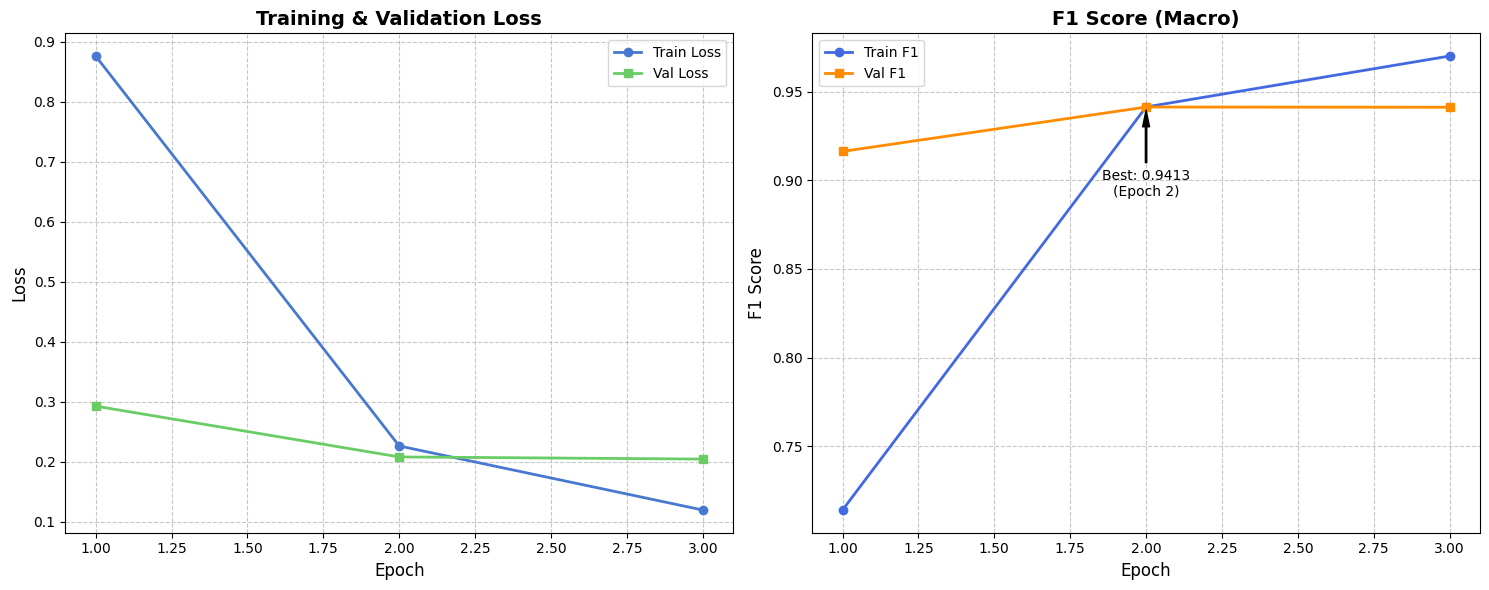

✅ 그래프가 다음 경로에 저장되었습니다: ../models/kcelectra_v2022_experiment\training_history_plot.png


In [20]:
import matplotlib.pyplot as plt

# 1. 결과 데이터프레임 변환
history_df = pd.DataFrame(history)

# 2. 저장 폴더 확인 (save_dir 내에 저장하도록 변경)
save_path = os.path.join(CONFIG['save_dir'], 'training_history_plot.png')

# 3. 그래프 스타일 및 폰트 설정
plt.style.use('seaborn-v0_8-muted') # 깔끔한 테마 적용
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 왼쪽: Loss 그래프 ---
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(history_df['epoch'], history_df['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- 오른쪽: F1 Score 그래프 ---
axes[1].plot(history_df['epoch'], history_df['train_f1'], 'o-', label='Train F1', linewidth=2, color='royalblue')
axes[1].plot(history_df['epoch'], history_df['val_f1'], 's-', label='Val F1', linewidth=2, color='darkorange')

# 최고 성능 지점 표시 (Best F1)
best_f1_val = history_df['val_f1'].max()
best_f1_epoch = history_df.loc[history_df['val_f1'].idxmax(), 'epoch']
axes[1].annotate(f'Best: {best_f1_val:.4f}\n(Epoch {int(best_f1_epoch)})', 
                 xy=(best_f1_epoch, best_f1_val), 
                 xytext=(best_f1_epoch, best_f1_val - 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 ha='center')

axes[1].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 전체 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'✅ 그래프가 다음 경로에 저장되었습니다: {save_path}')

In [21]:
# 1. 최적의 모델 불러오기
# CONFIG['save_dir']에 저장된 KcELECTRA 모델을 로드합니다.
print(f"최고 성능 모델 로드 중... ({CONFIG['save_dir']})")
model = AutoModelForSequenceClassification.from_pretrained(CONFIG['save_dir'])
model.to(device)
model.eval()

# 2. 테스트 데이터 예측 진행
test_preds = []

print("테스트 데이터 예측 시작...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="[Predicting]"):
        # KcELECTRA의 성능을 위해 input_ids, attention_mask, token_type_ids를 모두 사용합니다.
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        
        outputs = model(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            token_type_ids=token_type_ids
        )
        
        logits = outputs.logits
        # 가장 높은 점수를 가진 클래스 선택
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)

# 3. submission.csv 파일 불러와서 채우기
# 데이터 경로가 정확한지 확인해 주세요!
submission = pd.read_csv('../data/raw/submission.csv') 

# 예측값 채워넣기 (0~4)
submission['class'] = test_preds

# 4. 최종 결과 저장
submission_file_name = f"submission_{CONFIG['run_name']}_f1_{best_val_f1:.4f}.csv"
submission.to_csv(submission_file_name, index=False)

print("-" * 30)
print(f"✅ 제출 파일 생성 완료: {submission_file_name}")
print(f"📊 예측 결과 분포:\n{submission['class'].value_counts().sort_index()}")
print("-" * 30)
print(submission.head())

최고 성능 모델 로드 중... (../models/kcelectra_v2022_experiment)
테스트 데이터 예측 시작...


[Predicting]:   0%|          | 0/32 [00:00<?, ?it/s]

------------------------------
✅ 제출 파일 생성 완료: submission_KcELECTRA-v2022-F1-v1_f1_0.9413.csv
📊 예측 결과 분포:
class
0     96
1    126
2     99
3    117
4     62
Name: count, dtype: int64
------------------------------
     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      4
4  t_004      1


In [22]:
import torch.nn.functional as F

# --- 설정값 (Phase 1 Logic Ablation) ---
THRESHOLD = 0.6  # 0.6 미만 확신 시 일상 대화(4)로 분류
NORMAL_CLASS = 4
# ---------------------------------------

# 1. 최적의 모델 불러오기
print(f"최고 성능 모델 로드 중... ({CONFIG['save_dir']})")
model = AutoModelForSequenceClassification.from_pretrained(CONFIG['save_dir'])
model.to(device)
model.eval()

# 2. 테스트 데이터 예측 진행 (Threshold 적용)
test_preds = []
confidence_scores = [] 

print(f"테스트 데이터 예측 시작... (Threshold: {THRESHOLD})")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="[Predicting]"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device) # KcELECTRA 특성 반영
        
        outputs = model(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            token_type_ids=token_type_ids
        )
        logits = outputs.logits
        
        # 확률값으로 변환 (Softmax)
        probs = F.softmax(logits, dim=1)
        
        # 가장 높은 확률과 해당 인덱스(클래스) 추출
        max_probs, preds = torch.max(probs, dim=1)
        
        max_probs = max_probs.cpu().numpy()
        preds = preds.cpu().numpy()

        # Threshold 로직 적용 (Phase 1 핵심)
        for prob, pred in zip(max_probs, preds):
            # 예측이 0~3(범죄/폭력)인데 확신(prob)이 낮으면 일상(4)으로 변경
            if pred < NORMAL_CLASS and prob < THRESHOLD:
                test_preds.append(NORMAL_CLASS)
            else:
                test_preds.append(pred)
            confidence_scores.append(prob)

# 3. submission.csv 파일 불러와서 채우기
submission = pd.read_csv('../data/raw/submission.csv') 
submission['class'] = test_preds

# 4. 최종 결과 저장 (파일명에 Threshold 정보 명시)
submission_file_name = f"submission_{CONFIG['run_name']}_f1_{best_val_f1:.4f}_th_{THRESHOLD}.csv"
submission.to_csv(submission_file_name, index=False)

print("-" * 30)
print(f"✅ 제출 파일 생성 완료: {submission_file_name}")
print(f"📊 클래스별 분포:\n{submission['class'].value_counts().sort_index()}")
print(f"💡 평균 확신도(Confidence): {sum(confidence_scores)/len(confidence_scores):.4f}")
print("-" * 30)
print(submission.head())

최고 성능 모델 로드 중... (../models/kcelectra_v2022_experiment)
테스트 데이터 예측 시작... (Threshold: 0.6)


[Predicting]:   0%|          | 0/32 [00:00<?, ?it/s]

------------------------------
✅ 제출 파일 생성 완료: submission_KcELECTRA-v2022-F1-v1_f1_0.9413_th_0.6.csv
📊 클래스별 분포:
class
0     92
1    123
2     96
3    112
4     77
Name: count, dtype: int64
💡 평균 확신도(Confidence): 0.9355
------------------------------
     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      4
4  t_004      1


In [23]:
# 1. 테스트 데이터 원문 불러오기 (경로를 본인의 환경에 맞게 확인하세요)
test_df = pd.read_csv('../data/raw/test.csv') 

# 2. 예측 결과와 원문을 합친 분석용 데이터프레임 생성
analysis_df = pd.DataFrame({
    'text': test_df['conversation'],
    'pred_class': test_preds,
    'confidence': confidence_scores  # 아까 저장한 확신도 점수
})

# 3. Class 4(일상 대화)로 분류된 샘플만 필터링
normal_samples = analysis_df[analysis_df['pred_class'] == 4]

print(f"📊 전체 {len(test_preds)}건 중 일상 대화로 분류된 건수: {len(normal_samples)}건")
print("-" * 50)

# 4. 상위 10개 예시 문장 출력
if len(normal_samples) > 0:
    # 확신도가 높은 순서대로 5개, 낮은 순서대로 5개 보여주면 분석에 더 좋습니다.
    print("✅ [확신도 높은 일상 대화 예시]")
    display(normal_samples.sort_values(by='confidence', ascending=False).head(5))
    
    print("\n⚠️ [확신도 낮은 일상 대화 예시 - THRESHOLD에 의해 걸러진 것들]")
    display(normal_samples.sort_values(by='confidence', ascending=True).head(5))
else:
    print("❌ 일상 대화로 분류된 문장이 없습니다. THRESHOLD를 더 높여보세요!")

📊 전체 500건 중 일상 대화로 분류된 건수: 77건
--------------------------------------------------
✅ [확신도 높은 일상 대화 예시]


,text,pred_class,confidence
167,와 오늘 괜히 기분히 좋네 닐씨가 좋아서 그런가 그냥 오늘 컨디션도 좋고 날씨도 딱...,4,0.989951
414,지은씨 이번 주말에 뭐 해요 저 약속은 없어요 그러면 같이 영화볼래요 요즘 재미있는...,4,0.989689
437,오늘 뭐하냐 나 오늘 친구랑 동물원 가는데 오 어디 어린이대공원이냐 아니아니 에버랜...,4,0.989681
48,나 호랑이 보러 가고 싶어 갑자기 호랑이 좋아했나 원래 내가 원래 동물을 좋아하잖아...,4,0.989428
415,오늘 나한테 설거지를 시키기에 잔을 일부러 깨버렸어. 설거지를 억지로 하게 되어 화...,4,0.989395



⚠️ [확신도 낮은 일상 대화 예시 - THRESHOLD에 의해 걸러진 것들]


,text,pred_class,confidence
262,너 이번 과제 도와주지 않으면 저번 일 이야기할 거야 네가 그 일을 어떻게 아는데?...,4,0.441474
90,좋은 아침 좋지 않아 왜 그래 무슨 일 있어 또 산더미처럼 들어가서 잠을 못 잤지 ...,4,0.453796
346,아 대회 참여하는데 일정이 늦쳐졌대 그래 얼마나 늦쳐졌는데 원래 수요일부터 금요일까...,4,0.455525
68,옥상에서 사람이 떨어졌어요. 사람이 떨어졌다고요? 위치가 어디세요? 경기도 광주시 ...,4,0.484992
315,애들아 여기는 내가 쏠테니까 마음껏 먹어 예지야 고마워! 넌 여전히 통이 크구나. ...,4,0.491755


PCA 분석용 데이터 수집 중...


  0%|          | 0/32 [00:00<?, ?it/s]

PCA 변환 완료! 데이터 형태: (500, 2)


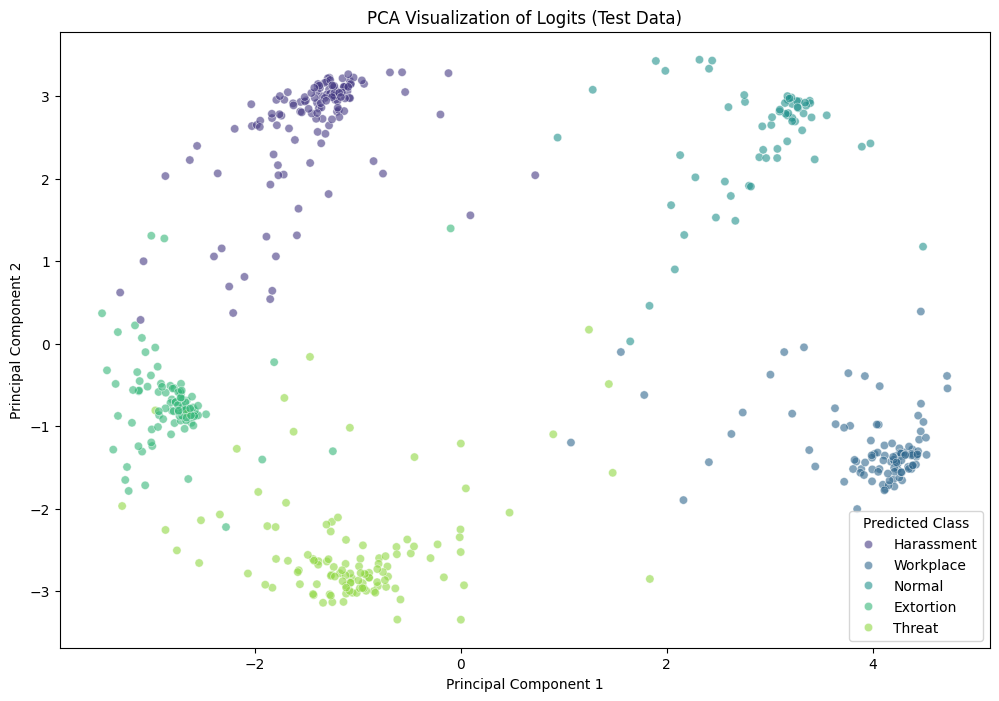

In [24]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터를 담을 리스트 초기화
logits_list = []
test_preds = []

model.eval()
print("PCA 분석용 데이터 수집 중...")

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
        # [중요] 모델의 출력값(Logits)을 CPU로 옮겨서 저장합니다.
        logits = outputs.logits.cpu().numpy()
        logits_list.append(logits)
        
        # 기존 예측값 저장 (Threshold 미적용 원본)
        preds = np.argmax(logits, axis=1)
        test_preds.extend(preds)

# 2. 리스트를 하나의 큰 행렬로 합칩니다. (샘플 수, 5)
logits_array = np.vstack(logits_list)

# 3. PCA 실행 (5차원 -> 2차원)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(logits_array)

print(f"PCA 변환 완료! 데이터 형태: {pca_features.shape}")

# 4. 시각화
plt.figure(figsize=(12, 8))
# 라벨 이름 매핑
label_names = {0: 'Extortion', 1: 'Harassment', 2: 'Workplace', 3: 'Threat', 4: 'Normal'}
current_labels = [label_names[p] for p in test_preds]

sns.scatterplot(
    x=pca_features[:, 0], 
    y=pca_features[:, 1], 
    hue=current_labels, 
    palette='viridis',
    alpha=0.6
)
plt.title("PCA Visualization of Logits (Test Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Predicted Class")
plt.show()

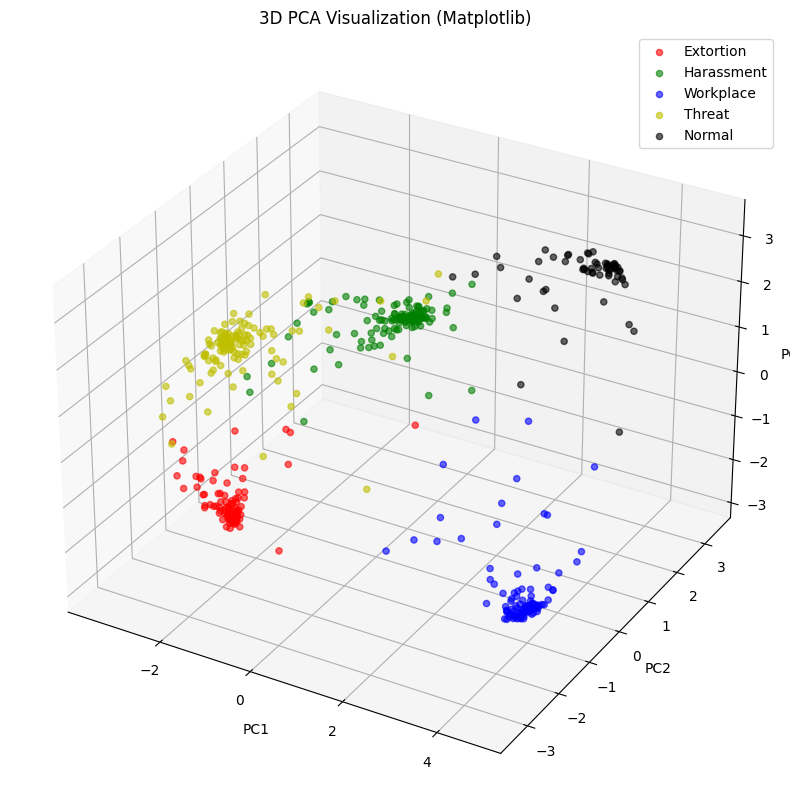

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # 3D 설정을 위한 모듈

# 1. 3차원 PCA 수행
pca_3d = PCA(n_components=3)
pca_features_3d = pca_3d.fit_transform(logits_array)

# 2. 그래프 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 클래스별 색상 및 이름 설정
colors = ['r', 'g', 'b', 'y', 'black'] # 4번(Normal)은 검은색(black)으로 설정하여 눈에 띄게 함
label_names = ['Extortion', 'Harassment', 'Workplace', 'Threat', 'Normal']

# 3. 클래스별로 루프를 돌며 점 찍기
for i in range(5):
    # 해당 클래스에 해당하는 인덱스만 추출
    idx = np.where(np.array(test_preds) == i)
    ax.scatter(pca_features_3d[idx, 0], 
               pca_features_3d[idx, 1], 
               pca_features_3d[idx, 2], 
               c=colors[i], 
               label=label_names[i], 
               alpha=0.6, 
               s=20)

ax.set_title("3D PCA Visualization (Matplotlib)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()

plt.show()